0.0
2.385841179591795e-06
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
2.5436200107243234e-07
2.5436200107243234e-07
5.087240021448647e-07
5.087240021448647e-07
3.052344012869188e-06
3.052344012869188e-06
5.595964023593512e-06
5.595964023593512e-06
1.6671346389358694e-05
1.6671346389358694e-05
2.7746728755123875e-05
2.7746728755123875e-05
3.8822111120889056e-05
3.8822111120889056e-05
7.21975496957565e-05
7.21975496957565e-05
6.18970696239179e-05
6.18970696239179e-05
6.18970696239179e-05
8.497202812694673e-05
8.497202812694673e-05
8.497202812694673e-05
7.778107468624203e-05
7.778107468624203e-05
7.778107468624203e-05
7.778107468624203e-05
9.366507974856617e-05
9.366507974856617e-05
9.366507974856617e-05
0.0001095490848108903
0.0001095490848108903
0.0001095490848108903
0.00012543308987321444
0.00012543308987321444
0.0001693487613182597
0.0001693487613182597
0.00021326443276330497
0.

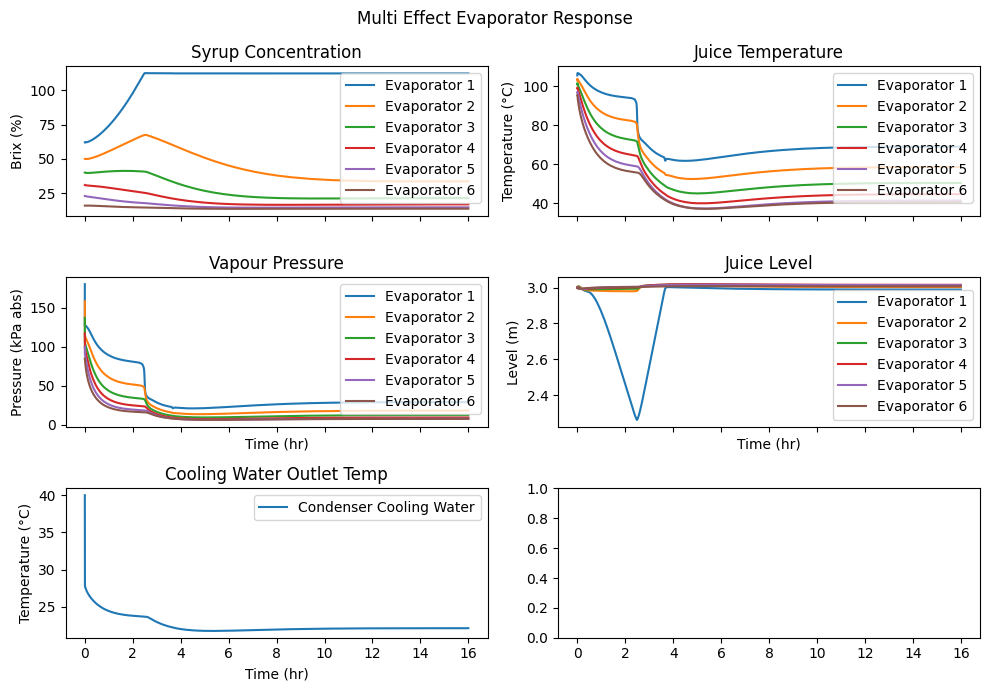

In [2]:
# MEE Model based on Smith (2000) - 6 effects

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from MEE_Thermo_Func import fP_eq, fT_eq, f_PJ_eq, fh, fdhvap, fh_ev, fcP, frho, fT_eq_w, fdhvap_w

# Parameters
R = 8.314 * (1e3 / 18)
alpha = 1e2
U = 700 * 3600 / 1e6

Dves = 5.5
Vol = 120
CrossA = np.pi * Dves**2 / 4
Ntubes = 7550
Ltubes = 2
Dtubes = 42e-3
A = Ntubes * Ltubes * np.pi * Dtubes

# Condenser Parameters
U_cond = 2500 * 1e-6 * 3600   # MJ/(hr·m²·°C)
N_cond = 400
D_cond = 25.4e-3
L_cond = 2.4
A_cond = N_cond * np.pi * D_cond * L_cond
V_cond = N_cond * np.pi * D_cond**2 / 4 * L_cond
rho_cw = 1        # t/m³
cp_cw  = 4.187    # MJ/(t·°C)
FCW = 1500        # t/hr
Tin_cw = 20       # °C

# Evaporator Inputs/Variables
x = [0.5, 1, 1, 1, 1, 1]
P_upstream = 180
V_bleed = 5
FJ_in = 100
Bx_in = 13
TJ_in = 100

controllers = {
    'LJ_1': {'Kc': -1000, 'Ti': -100, 'B': 22, 'Lower': 0, 'Upper': 100},
    'LJ_2': {'Kc': -1000, 'Ti': -100, 'B': 35, 'Lower': 0, 'Upper': 100},
    'LJ_3': {'Kc': -1000, 'Ti': -100, 'B': 48, 'Lower': 0, 'Upper': 100},
    'LJ_4': {'Kc': -1000, 'Ti': -100, 'B': 61, 'Lower': 0, 'Upper': 100},
    'LJ_5': {'Kc': -1000, 'Ti': -100, 'B': 74, 'Lower': 0, 'Upper': 100},
    'LJ_6': {'Kc': -1000, 'Ti': -100, 'B': 87, 'Lower': 0, 'Upper': 100}
}

class Evaporator:
    def __init__(self, x, FJ_in, Bx_in, TJ_in, V_bleed, P_upstream, FCW, Tin_cw, controllers):

        self.x = x
        self.FJ_in = FJ_in
        self.Bx_in = Bx_in
        self.TJ_in = TJ_in
        self.V_bleed = V_bleed
        self.P_upstream = P_upstream
        self.LJ_SP = 3
        self.FCW = FCW
        self.Tin_cw = Tin_cw
        self.controllers = controllers
        self.Flow_out = np.array([])

    def ODEs(self, t, X):

        print(t)

        #-----------------------------------------------------
        # controllers

        FJ_out = np.zeros(6)

        # LJ_1: Level control
        LJ_1_error = self.LJ_SP - X[3]
        FJ_1_SP = self.controllers['LJ_1']['Kc'] * LJ_1_error + 1/self.controllers['LJ_1']['Ti'] * X[4] + self.controllers['LJ_1']['B']
        if FJ_1_SP < self.controllers['LJ_1']['Lower']:
            FJ_1_SP = self.controllers['LJ_1']['Lower']
            LJ_1_error = 0
        elif FJ_1_SP > self.controllers['LJ_1']['Upper']:
            FJ_1_SP = self.controllers['LJ_1']['Upper']
            LJ_1_error = 0

        FJ_out[0] = FJ_1_SP

        # LJ_2: Level control
        LJ_2_error = self.LJ_SP - X[8]
        FJ_2_SP = self.controllers['LJ_2']['Kc'] * LJ_2_error + 1/self.controllers['LJ_2']['Ti'] * X[9] + self.controllers['LJ_2']['B']
        if FJ_2_SP < self.controllers['LJ_2']['Lower']:
            FJ_2_SP = self.controllers['LJ_2']['Lower']
            LJ_2_error = 0
        elif FJ_2_SP > self.controllers['LJ_2']['Upper']:
            FJ_2_SP = self.controllers['LJ_2']['Upper']
            LJ_2_error = 0

        FJ_out[1] = FJ_2_SP

        # LJ_3: Level control
        LJ_3_error = self.LJ_SP - X[13]
        FJ_3_SP = self.controllers['LJ_3']['Kc'] * LJ_3_error + 1/self.controllers['LJ_3']['Ti'] * X[14] + self.controllers['LJ_3']['B']
        if FJ_3_SP < self.controllers['LJ_3']['Lower']:
            FJ_3_SP = self.controllers['LJ_3']['Lower']
            LJ_3_error = 0
        elif FJ_3_SP > self.controllers['LJ_3']['Upper']:
            FJ_3_SP = self.controllers['LJ_3']['Upper']
            LJ_3_error = 0

        FJ_out[2] = FJ_3_SP

        # LJ_4: Level control
        LJ_4_error = self.LJ_SP - X[18]
        FJ_4_SP = self.controllers['LJ_4']['Kc'] * LJ_4_error + 1/self.controllers['LJ_4']['Ti'] * X[19] + self.controllers['LJ_4']['B']
        if FJ_4_SP < self.controllers['LJ_4']['Lower']:
            FJ_4_SP = self.controllers['LJ_4']['Lower']
            LJ_4_error = 0
        elif FJ_4_SP > self.controllers['LJ_4']['Upper']:
            FJ_4_SP = self.controllers['LJ_4']['Upper']
            LJ_4_error = 0

        FJ_out[3] = FJ_4_SP

        # LJ_5: Level control
        LJ_5_error = self.LJ_SP - X[23]
        FJ_5_SP = self.controllers['LJ_5']['Kc'] * LJ_5_error + 1/self.controllers['LJ_5']['Ti'] * X[24] + self.controllers['LJ_5']['B']
        if FJ_5_SP < self.controllers['LJ_5']['Lower']:
            FJ_5_SP = self.controllers['LJ_5']['Lower']
            LJ_5_error = 0
        elif FJ_5_SP > self.controllers['LJ_5']['Upper']:
            FJ_5_SP = self.controllers['LJ_5']['Upper']
            LJ_5_error = 0

        FJ_out[4] = FJ_5_SP

        # LJ_6: Level control
        LJ_6_error = self.LJ_SP - X[28]
        FJ_6_SP = self.controllers['LJ_6']['Kc'] * LJ_6_error + 1/self.controllers['LJ_6']['Ti'] * X[29] + self.controllers['LJ_6']['B']
        if FJ_6_SP < self.controllers['LJ_6']['Lower']:
            FJ_6_SP = self.controllers['LJ_6']['Lower']
            LJ_6_error = 0
        elif FJ_6_SP > self.controllers['LJ_6']['Upper']:
            FJ_6_SP = self.controllers['LJ_6']['Upper']
            LJ_6_error = 0

        FJ_out[5] = FJ_6_SP

        #-----------------------------------------------------
        # Initialise arrays
        mJ = np.zeros(6)
        Vev = np.zeros(6)
        PST = np.zeros(6)
        TST = np.zeros(6)
        Q = np.zeros(6)
        FST = np.zeros(6)
        dmJ_dt = np.zeros(6)
        Vdraw_total = np.zeros(6)

        #-----------------------------------------------------
        # Evaporator 1
        P_upstream = self.P_upstream
        mJ[0] = X[3] * frho(X[1], X[0]) * CrossA
        Vev[0] = alpha * (f_PJ_eq(X[1], X[0]) - X[2])
        PST[0] = self.x[0] * P_upstream + (1 - self.x[0]) * fP_eq(X[1])
        TST[0] = fT_eq(PST[0])
        Q[0] = U * A * (TST[0] - X[1])
        FST[0] = Q[0]/fdhvap(TST[0])
        dmJ_dt[0] = FJ_out[1] - FJ_out[0] - Vev[0]

        # Evaporator 2
        mJ[1] = X[8] * frho(X[6], X[5]) * CrossA
        Vev[1] = alpha * (f_PJ_eq(X[6], X[5]) - X[7])
        PST[1] = self.x[1] * X[2] + (1 - self.x[1]) * fP_eq(X[6])
        TST[1] = fT_eq(PST[1])
        Q[1] = U * A * (TST[1] - X[6])
        FST[1] = Q[1]/fdhvap(TST[1])
        dmJ_dt[1] = FJ_out[2] - FJ_out[1] - Vev[1]
        Vdraw_total[0] = FST[1] + self.V_bleed

        # Evaporator 3
        mJ[2] = X[13] * frho(X[11], X[10]) * CrossA
        Vev[2] = alpha * (f_PJ_eq(X[11], X[10]) - X[12])
        PST[2] = self.x[2] * X[7] + (1 - self.x[2]) * fP_eq(X[11])
        TST[2] = fT_eq(PST[2])
        Q[2] = U * A * (TST[2] - X[11])
        FST[2] = Q[2]/fdhvap(TST[2])
        dmJ_dt[2] = FJ_out[3] - FJ_out[2] - Vev[2]
        Vdraw_total[1] = FST[2] + self.V_bleed

        # Evaporator 4
        mJ[3] = X[18] * frho(X[16], X[15]) * CrossA
        Vev[3] = alpha * (f_PJ_eq(X[16], X[15]) - X[17])
        PST[3] = self.x[3] * X[12] + (1 - self.x[3]) * fP_eq(X[16])
        TST[3] = fT_eq(PST[3])
        Q[3] = U * A * (TST[3] - X[16])
        FST[3] = Q[3]/fdhvap(TST[3])
        dmJ_dt[3] = FJ_out[4] - FJ_out[3] - Vev[3]
        Vdraw_total[2] = FST[3] + self.V_bleed

        # Evaporator 5
        mJ[4] = X[23] * frho(X[21], X[20]) * CrossA
        Vev[4] = alpha * (f_PJ_eq(X[21], X[20]) - X[22])
        PST[4] = self.x[4] * X[17] + (1 - self.x[4]) * fP_eq(X[21])
        TST[4] = fT_eq(PST[4])
        Q[4] = U * A * (TST[4] - X[21])
        FST[4] = Q[4]/fdhvap(TST[4])
        dmJ_dt[4] = FJ_out[5] - FJ_out[4] - Vev[4]
        Vdraw_total[3] = FST[4] + self.V_bleed

        # Evaporator 6
        mJ[5] = X[28] * frho(X[26], X[25]) * CrossA
        Vev[5] = alpha * (f_PJ_eq(X[26], X[25]) - X[27])
        PST[5] = self.x[5] * X[22] + (1 - self.x[5]) * fP_eq(X[26])
        TST[5] = fT_eq(PST[5])
        Q[5] = U * A * (TST[5] - X[26])
        FST[5] = Q[5]/fdhvap(TST[5])
        dmJ_dt[5] = self.FJ_in - FJ_out[5] - Vev[5]
        Vdraw_total[4] = FST[5] + self.V_bleed

        # Condenser (on EV6 vapour outlet)
        PST_cond = X[27]                       # steam pressure into condenser = P6
        Tout     = X[30]                       # new state: cooling water outlet temp
        TST_cond = fT_eq_w(PST_cond)
        LMTD     = (Tout - self.Tin_cw) / np.log((TST_cond - self.Tin_cw) / (TST_cond - Tout))
        Q_cond   = U_cond * A_cond * LMTD
        FST_cond = Q_cond / fdhvap_w(TST_cond)
        dTout_dt = (self.FCW / V_cond) * (self.Tin_cw - Tout) + Q_cond / (rho_cw * V_cond * cp_cw)

        Vdraw_total[5] = FST_cond

        dX_dt = np.zeros(31)

        # X = [Bx1, TJ1, P1, LJ1, e_LJ1, Bx2, TJ2, P2, LJ2, e_LJ2, Bx3, TJ3, P3, LJ3, e_LJ3,
        #      Bx4, TJ4, P4, LJ4, e_LJ4, Bx5, TJ5, P5, LJ5, e_LJ5, Bx6, TJ6, P6, LJ6, e_LJ6, Tout]

        # dBx1/dt
        dX_dt[0] = (FJ_out[1] * X[5] - FJ_out[0] * X[0] - X[0] * dmJ_dt[0]) / mJ[0]
        # dTJ1/dt
        dX_dt[1] = (FJ_out[1] * fh(X[6], X[5]) - FJ_out[0] * fh(X[1], X[0]) - Vev[0] * fh_ev(X[1], X[0]) + Q[0]) / (mJ[0] * fcP(X[1], X[0])) - X[1] * dmJ_dt[0] / mJ[0]
        # dP1/dt
        dX_dt[2] = (R * X[1] / Vol) * (Vev[0] - Vdraw_total[0]) + X[2] / X[1] * dX_dt[1]
        # dLJ1/dt
        dX_dt[3] = dmJ_dt[0] / (frho(X[1], X[0]) * CrossA)
        # d(e_LJ1)/dt
        dX_dt[4] = LJ_1_error

        # dBx2/dt
        dX_dt[5] = (FJ_out[2] * X[10] - FJ_out[1] * X[5] - X[5] * dmJ_dt[1]) / mJ[1]
        # dTJ2/dt
        dX_dt[6] = (FJ_out[2] * fh(X[11], X[10]) - FJ_out[1] * fh(X[6], X[5]) - Vev[1] * fh_ev(X[6], X[5]) + Q[1]) / (mJ[1] * fcP(X[6], X[5])) - X[6] * dmJ_dt[1] / mJ[1]
        # dP2/dt
        dX_dt[7] = (R * X[6] / Vol) * (Vev[1] - Vdraw_total[1]) + X[7] / X[6] * dX_dt[6]
        # dLJ2/dt
        dX_dt[8] = dmJ_dt[1] / (frho(X[6], X[5]) * CrossA)
        # d(e_LJ2)/dt
        dX_dt[9] = LJ_2_error

        # dBx3/dt
        dX_dt[10] = (FJ_out[3] * X[15] - FJ_out[2] * X[10] - X[10] * dmJ_dt[2]) / mJ[2]
        # dTJ3/dt
        dX_dt[11] = (FJ_out[3] * fh(X[16], X[15]) - FJ_out[2] * fh(X[11], X[10]) - Vev[2] * fh_ev(X[11], X[10]) + Q[2]) / (mJ[2] * fcP(X[11], X[10])) - X[11] * dmJ_dt[2] / mJ[2]
        # dP3/dt
        dX_dt[12] = (R * X[11] / Vol) * (Vev[2] - Vdraw_total[2]) + X[12] / X[11] * dX_dt[11]
        # dLJ3/dt
        dX_dt[13] = dmJ_dt[2] / (frho(X[11], X[10]) * CrossA)
        # d(e_LJ3)/dt
        dX_dt[14] = LJ_3_error

        # dBx4/dt
        dX_dt[15] = (FJ_out[4] * X[20] - FJ_out[3] * X[15] - X[15] * dmJ_dt[3]) / mJ[3]
        # dTJ4/dt
        dX_dt[16] = (FJ_out[4] * fh(X[21], X[20]) - FJ_out[3] * fh(X[16], X[15]) - Vev[3] * fh_ev(X[16], X[15]) + Q[3]) / (mJ[3] * fcP(X[16], X[15])) - X[16] * dmJ_dt[3] / mJ[3]
        # dP4/dt
        dX_dt[17] = (R * X[16] / Vol) * (Vev[3] - Vdraw_total[3]) + X[17] / X[16] * dX_dt[16]
        # dLJ4/dt
        dX_dt[18] = dmJ_dt[3] / (frho(X[16], X[15]) * CrossA)
        # d(e_LJ4)/dt
        dX_dt[19] = LJ_4_error

        # dBx5/dt
        dX_dt[20] = (FJ_out[5] * X[25] - FJ_out[4] * X[20] - X[20] * dmJ_dt[4]) / mJ[4]
        # dTJ5/dt
        dX_dt[21] = (FJ_out[5] * fh(X[26], X[25]) - FJ_out[4] * fh(X[21], X[20]) - Vev[4] * fh_ev(X[21], X[20]) + Q[4]) / (mJ[4] * fcP(X[21], X[20])) - X[21] * dmJ_dt[4] / mJ[4]
        # dP5/dt
        dX_dt[22] = (R * X[21] / Vol) * (Vev[4] - Vdraw_total[4]) + X[22] / X[21] * dX_dt[21]
        # dLJ5/dt
        dX_dt[23] = dmJ_dt[4] / (frho(X[21], X[20]) * CrossA)
        # d(e_LJ5)/dt
        dX_dt[24] = LJ_5_error

        # dBx6/dt
        dX_dt[25] = (self.FJ_in * self.Bx_in - FJ_out[5] * X[25] - X[25] * dmJ_dt[5]) / mJ[5]
        # dTJ6/dt
        dX_dt[26] = (self.FJ_in * fh(self.TJ_in, self.Bx_in) - FJ_out[5] * fh(X[26], X[25]) - Vev[5] * fh_ev(X[26], X[25]) + Q[5]) / (mJ[5] * fcP(X[26], X[25])) - X[26] * dmJ_dt[5] / mJ[5]
        # dP6/dt
        dX_dt[27] = (R * X[26] / Vol) * (Vev[5] - Vdraw_total[5]) + X[27] / X[26] * dX_dt[26]
        # dLJ6/dt
        dX_dt[28] = dmJ_dt[5] / (frho(X[26], X[25]) * CrossA)
        # d(e_LJ6)/dt
        dX_dt[29] = LJ_6_error

        # dTout/dt  (cooling water outlet temperature – condenser)
        dX_dt[30] = dTout_dt

        return [dX_dt[0], dX_dt[1], dX_dt[2], dX_dt[3], dX_dt[4], dX_dt[5], dX_dt[6], dX_dt[7], dX_dt[8], dX_dt[9], dX_dt[10], dX_dt[11], dX_dt[12], dX_dt[13], dX_dt[14], dX_dt[15], dX_dt[16], dX_dt[17], dX_dt[18], dX_dt[19], dX_dt[20], dX_dt[21], dX_dt[22], dX_dt[23], dX_dt[24], dX_dt[25], dX_dt[26], dX_dt[27], dX_dt[28], dX_dt[29], dX_dt[30]]


y0 = [62, 105.6, P_upstream, 3, 0,
      50, 103.0, 158, 3, 0,
      40, 101.0, 137, 3, 0,
      31, 99.0, 117, 3, 0,
      23, 97.0, 100, 3, 0,
      16, 95.6, 85, 3, 0,
      40]  # [Bx, TJ, P, LJ, integral of LJ error] x6, then Tout

t_span = (0, 16)

evaporator = Evaporator(x, FJ_in, Bx_in, TJ_in, V_bleed, P_upstream, FCW, Tin_cw, controllers)
solution = solve_ivp(evaporator.ODEs, t_span, y0, method='BDF')

Bx_sol = np.zeros((len(solution.t), 6))
TJ_sol = np.zeros((len(solution.t), 6))
P_sol = np.zeros((len(solution.t), 6))
LJ_sol = np.zeros((len(solution.t), 6))
Tw_sol = np.zeros(len(solution.t))

Bx_sol[:, 0] = solution.y[0]
Bx_sol[:, 1] = solution.y[5]
Bx_sol[:, 2] = solution.y[10]
Bx_sol[:, 3] = solution.y[15]
Bx_sol[:, 4] = solution.y[20]
Bx_sol[:, 5] = solution.y[25]

TJ_sol[:, 0] = solution.y[1]
TJ_sol[:, 1] = solution.y[6]
TJ_sol[:, 2] = solution.y[11]
TJ_sol[:, 3] = solution.y[16]
TJ_sol[:, 4] = solution.y[21]
TJ_sol[:, 5] = solution.y[26]

P_sol[:, 0] = solution.y[2]
P_sol[:, 1] = solution.y[7]
P_sol[:, 2] = solution.y[12]
P_sol[:, 3] = solution.y[17]
P_sol[:, 4] = solution.y[22]
P_sol[:, 5] = solution.y[27]

LJ_sol[:, 0] = solution.y[3]
LJ_sol[:, 1] = solution.y[8]
LJ_sol[:, 2] = solution.y[13]
LJ_sol[:, 3] = solution.y[18]
LJ_sol[:, 4] = solution.y[23]
LJ_sol[:, 5] = solution.y[28]

Tw_sol = solution.y[30]

print('Final Bx:', Bx_sol[-1, :])
print('Final TJ:', TJ_sol[-1, :])
print('Final P:', P_sol[-1, :])
print('Final LJ:', LJ_sol[-1, :])
print('Final Tw:', Tw_sol[-1])

leg = ['Evaporator 1', 'Evaporator 2', 'Evaporator 3', 'Evaporator 4', 'Evaporator 5', 'Evaporator 6']

fig, axes = plt.subplots(3, 2, figsize=(10, 7), sharex=True)

axes[0, 0].plot(solution.t, Bx_sol)
axes[0, 0].set_ylabel('Brix (%)')
axes[0, 0].set_title('Syrup Concentration')
axes[0, 0].legend(leg)

axes[0, 1].plot(solution.t, TJ_sol)
axes[0, 1].set_ylabel('Temperature (°C)')
axes[0, 1].set_title('Juice Temperature')
axes[0, 1].legend(leg)

axes[1, 0].plot(solution.t, P_sol)
axes[1, 0].set_ylabel('Pressure (kPa abs)')
axes[1, 0].set_title('Vapour Pressure')
axes[1, 0].set_xlabel('Time (hr)')
axes[1, 0].legend(leg)

axes[1, 1].plot(solution.t, LJ_sol)
axes[1, 1].set_ylabel('Level (m)')
axes[1, 1].set_title('Juice Level')
axes[1, 1].set_xlabel('Time (hr)')
axes[1, 1].legend(leg)

axes[2, 0].plot(solution.t, Tw_sol)
axes[2, 0].set_ylabel('Temperature (°C)')
axes[2, 0].set_title('Cooling Water Outlet Temp')
axes[2, 0].set_xlabel('Time (hr)')
axes[2, 0].legend(['Condenser Cooling Water'])

fig.suptitle('Multi Effect Evaporator Response')
fig.tight_layout()
plt.show()